In [3]:
import pandas as pd
import numpy as np

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("healthcare_prescription_analytics_dataset.csv")

In [5]:
df.head()

,Prescription_ID,Patient_ID,Patient_Age,Age_Group,Gender,City,Department,Diagnosis,Medicine_Name,Medicine_Category,Dosage,Quantity,Unit_Price,Total_Medicine_Cost,Prescription_Date,Month,Season,Doctor_ID
0,RX000001,PAT01144,47,Adult,Female,Indore,General Medicine,Migraine,Pantoprazole,Antacid/PPI,40mg,13,321.57,4180.41,2025-11-24,Nov,Winter,DOC027
1,RX000001,PAT01144,47,Adult,Female,Indore,General Medicine,Migraine,Ondansetron,Antiemetic,250mg,12,139.62,1675.44,2025-11-24,Nov,Winter,DOC027
2,RX000002,PAT01274,35,Young Adult,Female,Hyderabad,Orthopedics,Fracture Follow-up,Calcium,Supplement,5ml,15,38.68,580.20,2026-01-24,Jan,Winter,DOC056
3,RX000002,PAT01274,35,Young Adult,Female,Hyderabad,Orthopedics,Fracture Follow-up,Vitamin D3,Vitamin/Supplement,10mg,9,53.88,484.92,2026-01-24,Jan,Winter,DOC056
4,RX000003,PAT01576,50,Adult,Female,Pune,ENT,Ear Infection,Paracetamol,Analgesic/Antipyretic,500mg,5,179.18,895.90,2026-03-01,Mar,Summer,DOC018


In [13]:
#1 Diagnoses with highest unique prescriptions
highest_unique_prescriptions=df.groupby("Diagnosis")["Prescription_ID"].nunique().sort_values(ascending=False)
print(highest_unique_prescriptions)

Diagnosis
Common Cold                654
Gastritis                  532
Pediatric Diarrhea         438
Viral Fever                418
Diabetic Neuropathy        407
Type 2 Diabetes            397
Thyroid Disorder           389
Bacterial Infection        378
Allergic Rhinitis          364
Sinusitis                  354
Pediatric Fever            348
Pediatric Cold             345
Asthma                     341
High Cholesterol           328
Heart Failure              310
Bronchitis                 307
Diarrhea                   301
Joint Pain                 300
Coronary Artery Disease    297
Migraine                   294
Hypertension               293
Respiratory Infection      283
Anemia                     273
COPD                       272
Muscle Spasm               271
Fracture Follow-up         270
Worm Infection             267
Body Pain                  261
Back Pain                  258
Eczema                     241
Fungal Infection           233
Acne                       23

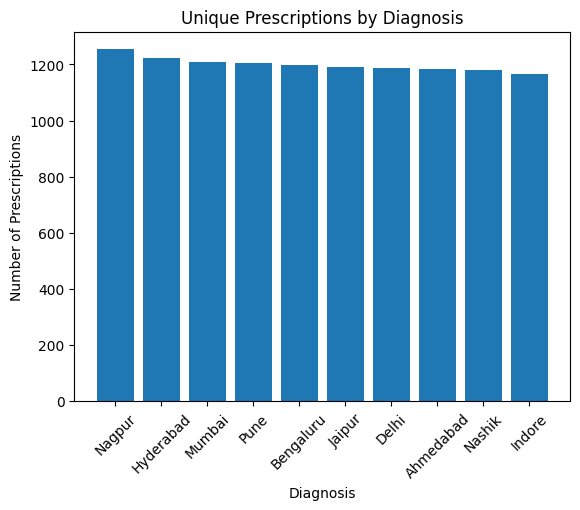

In [72]:
#1
highest_unique = df.groupby("Diagnosis")["Prescription_ID"].nunique().sort_values(ascending=False)
plt.bar(unique.index, unique.values)
plt.title("Unique Prescriptions by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Prescriptions")
plt.xticks(rotation=45)
plt.show()

In [14]:
#2 Departments with highest prescription volume
highest_prescription_volume = df.groupby("Department")["Prescription_ID"].nunique().sort_values(ascending=False)
print(highest_prescription_volume)

Department
General Medicine    2843
Pediatrics          1412
Cardiology          1238
Pulmonology         1210
Endocrinology       1201
ENT                 1191
Orthopedics         1110
Dermatology          941
Gastroenterology     854
Name: Prescription_ID, dtype: int64


In [15]:
#3 Departments with highest total medicine expenditure
highest_medicine_expenditure = df.groupby("Department")["Total_Medicine_Cost"].sum().sort_values(ascending=False)
print(highest_medicine_expenditure)

Department
General Medicine    17179178.03
Cardiology           8608065.55
Pulmonology          8465203.35
Endocrinology        7450427.29
Orthopedics          6460344.85
ENT                  6424575.27
Dermatology          5085307.56
Gastroenterology     4092026.98
Pediatrics           2836471.32
Name: Total_Medicine_Cost, dtype: float64


In [19]:
#4 Departments with highest average cost per prescription
highest_avg_cost = df.groupby(["Department", "Prescription_ID"])["Total_Medicine_Cost"].sum()
print(highest_avg_cost.groupby("Department").mean().sort_values(ascending=False))

Department
Pulmonology         6996.035826
Cardiology          6953.203191
Endocrinology       6203.519808
General Medicine    6042.623296
Orthopedics         5820.130495
Dermatology         5404.152561
ENT                 5394.269748
Gastroenterology    4791.600679
Pediatrics          2008.832380
Name: Total_Medicine_Cost, dtype: float64


In [20]:
#5 Average number of medicines per prescription by department
avg_no_of_medicines = df.groupby(["Department", "Prescription_ID"])["Medicine_Name"].nunique()
print(avg_no_of_medicines.groupby("Department").mean().sort_values(ascending=False))

Department
Pulmonology         3.666116
Cardiology          3.243134
General Medicine    3.172353
Endocrinology       2.955870
ENT                 2.945424
Orthopedics         2.894595
Gastroenterology    2.679157
Dermatology         2.658874
Pediatrics          2.481586
Name: Medicine_Name, dtype: float64


In [16]:
#6 Departments prescribing widest variety of medicine categories
variety_of_medicine = df.groupby("Department")["Medicine_Category"].nunique().sort_values(ascending=False)
print(variety_of_medicine)

Department
General Medicine    33
Cardiology          32
Endocrinology       32
Pediatrics          32
Orthopedics         31
Dermatology         30
ENT                 30
Gastroenterology    30
Pulmonology         30
Name: Medicine_Category, dtype: int64


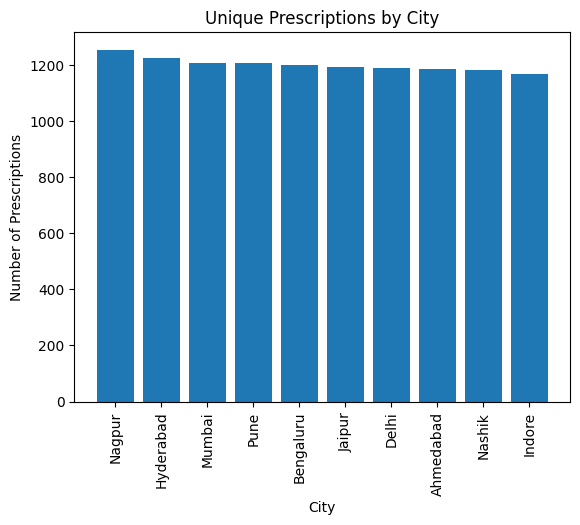

In [73]:
#9 Unique prescriptions by city — Bar Plot
unique = df.groupby("City")["Prescription_ID"].nunique().sort_values(ascending=False)
plt.bar(unique.index, unique.values)
plt.title("Unique Prescriptions by City")
plt.xlabel("City")
plt.ylabel("Number of Prescriptions")
plt.xticks(rotation=90)
plt.show()

In [17]:
#10 Cities with highest total medicine expenditure
highest_medicine_expenditure = df.groupby("City")["Total_Medicine_Cost"].sum().sort_values(ascending=False)
print(highest_medicine_expenditure)

City
Nagpur       7223000.43
Hyderabad    6806004.27
Mumbai       6797635.15
Delhi        6715855.68
Jaipur       6580520.64
Bengaluru    6542067.86
Ahmedabad    6537054.85
Pune         6517409.71
Indore       6463850.57
Nashik       6418201.04
Name: Total_Medicine_Cost, dtype: float64


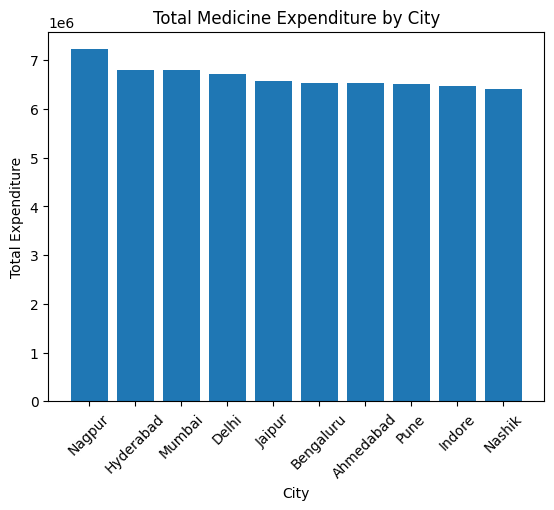

In [66]:
#10 by bar plot
medicine_exp = df.groupby("City")["Total_Medicine_Cost"].sum().sort_values(ascending=False)
plt.bar(medicine_exp.index, medicine_exp.values)
plt.title("Total Medicine Expenditure by City")
plt.xlabel("City")
plt.ylabel("Total Expenditure")
plt.xticks(rotation=45)
plt.show()

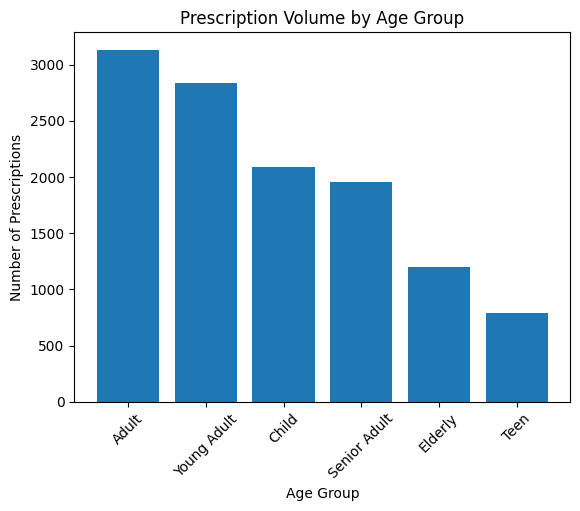

In [67]:
#15 Prescription volume across age groups — Bar Plot
volume = df.groupby("Age_Group")["Prescription_ID"].nunique().sort_values(ascending=False)
plt.bar(volume.index, volume.values)
plt.title("Prescription Volume by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Prescriptions")
plt.xticks(rotation=45)
plt.show()

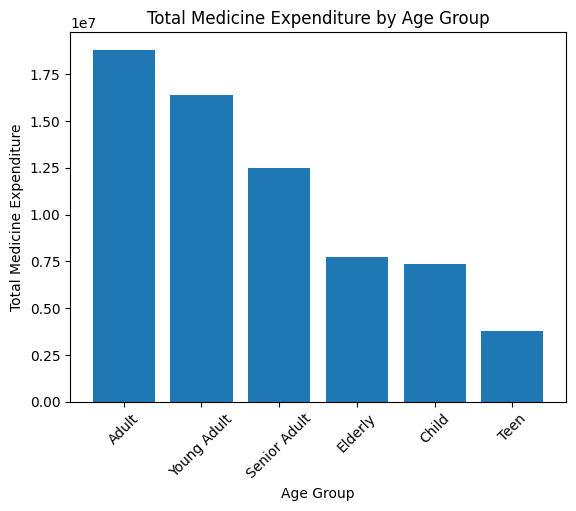

In [68]:
#16 Age group with highest total medicine expenditure — Bar Plot
age_group = df.groupby("Age_Group")["Total_Medicine_Cost"].sum().sort_values(ascending=False)
plt.bar(age_group.index, age_group.values)
plt.title("Total Medicine Expenditure by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Medicine Expenditure")
plt.xticks(rotation=45)
plt.show()

In [22]:
#17 Average prescription cost by age group
avg_prescription_cost = df.groupby(["Age_Group", "Prescription_ID"])["Total_Medicine_Cost"].sum()
print(avg_prescription_cost.groupby("Age_Group").mean().sort_values(ascending=False))

Age_Group
Elderly         6465.748367
Senior Adult    6387.725780
Adult           6005.061281
Young Adult     5778.485460
Teen            4799.177434
Child           3529.788490
Name: Total_Medicine_Cost, dtype: float64


In [23]:
#21 Prescription volume, quantity and expenditure by gender
by_gender = df.groupby("Gender").agg(
    Prescription_Volume=("Prescription_ID", "nunique"),
    Total_Quantity=("Quantity", "sum"),
    Total_Expenditure=("Total_Medicine_Cost", "sum"))
print(by_gender)

        Prescription_Volume  Total_Quantity  Total_Expenditure
Gender                                                        
Female                 5810          137638        32073532.64
Male                   6066          144895        33826947.70
Other                   124            2982          701119.86


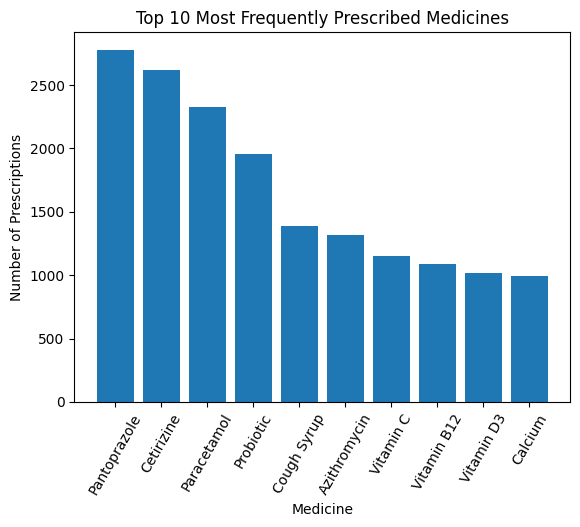

In [69]:
#25 Most frequently prescribed medicines — Bar Plot
frequently_prescribed = df.groupby("Medicine_Name")["Prescription_ID"].nunique().sort_values(ascending=False).head(10)
plt.bar(frequently_prescribed.index, frequently_prescribed.values)
plt.title("Top 10 Most Frequently Prescribed Medicines")
plt.xlabel("Medicine")
plt.ylabel("Number of Prescriptions")
plt.xticks(rotation=60)
plt.show()

In [25]:
#26 Medicines with highest total quantity
highest_quantity= df.groupby("Medicine_Name")["Quantity"].sum().sort_values(ascending=False)
print(highest_quantity)

Medicine_Name
Pantoprazole        25099
Cetirizine          23724
Paracetamol         21105
Probiotic           17797
Azithromycin        11917
                    ...  
PAIN RELIEF GEL         5
GLIMEPIRIDE             5
PANTAPRAZOLE            4
CETIRIZINE SYRUP        4
ZINC SYRUP              3
Name: Quantity, Length: 115, dtype: int64


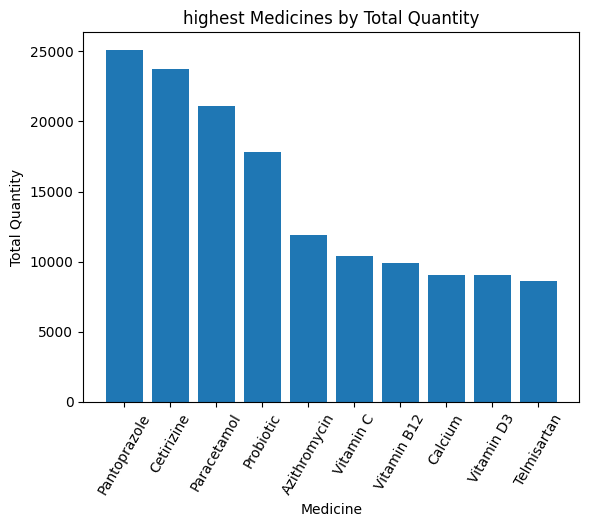

In [63]:
#26
highest_quantity = df.groupby("Medicine_Name")["Quantity"].sum().sort_values(ascending=False).head(10)
plt.bar(highest_quantity.index, highest_quantity.values)
plt.title("highest Medicines by Total Quantity")
plt.xlabel("Medicine")
plt.ylabel("Total Quantity")
plt.xticks(rotation=60)
plt.show()

In [26]:
#27 Medicines with highest total expenditure
highest_total_exp = df.groupby("Medicine_Name")["Total_Medicine_Cost"].sum().sort_values(ascending=False)
print(highest_total_exp)

Medicine_Name
Pantoprazole        5910083.96
Cetirizine          5477082.51
Paracetamol         4980508.54
Probiotic           4215731.70
Azithromycin        2747597.14
                       ...    
GLIMEPIRIDE             792.10
VITAMIN C SYRUP         783.12
BENZOYL PEROXIDE        770.21
CETIRIZINE SYRUP        603.27
ZINC SYRUP              538.71
Name: Total_Medicine_Cost, Length: 115, dtype: float64


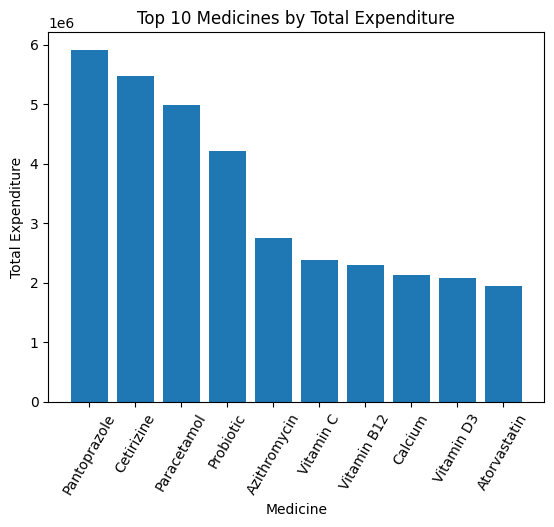

In [62]:
#27
hihest_total_exp = df.groupby("Medicine_Name")["Total_Medicine_Cost"].sum().sort_values(ascending=False).head(10)
plt.bar(hihest_total_exp.index, hihest_total_exp.values)
plt.title("Top 10 Medicines by Total Expenditure")
plt.xlabel("Medicine")
plt.ylabel("Total Expenditure")
plt.xticks(rotation=60)
plt.show()

In [27]:
#32 Categories with highest total expenditure
categories = df.groupby("Medicine_Category")["Total_Medicine_Cost"].sum().sort_values(ascending=False)
print(categories)

Medicine_Category
Vitamin/Supplement       7197629.10
Antacid/PPI              6080846.65
Antihistamine            5677892.26
Analgesic/Antipyretic    5161554.32
Supplement               4642885.04
Gut Health               4239333.12
Antibiotic               3754789.51
Antihypertensive         2595529.44
Dermatology              2555860.41
Antidiabetic             2435179.11
Bronchodilator           2330466.96
Antiplatelet             2319480.42
NSAID                    2073978.50
Statin                   1949906.70
Antiemetic               1929933.13
Anti-allergic            1823933.58
Steroid/Inhaler          1194463.35
Diuretic                 1157080.15
Muscle Relaxant           941845.85
Neuropathic Pain          806864.33
Thyroid Medicine          678401.86
Supportive Care           673504.99
Respiratory               637870.22
Anti-parasitic            620097.13
Pediatric Supplement      471501.85
Rehydration               433872.61
Pediatric                 433254.21
Antifungal

In [28]:
#38 Diagnosis and medicine category combinations occurring most often 
combination = df.groupby(["Diagnosis", "Medicine_Category"]).size().sort_values(ascending=False)
print(combination)

Diagnosis                Medicine_Category    
Type 2 Diabetes          Antidiabetic             694
Common Cold              Vitamin/Supplement       587
Pediatric Cold           Pediatric                582
Common Cold              Analgesic/Antipyretic    578
                         Respiratory              572
                                                 ... 
Coronary Artery Disease  Bronchodilator             1
                         ENT                        1
Migraine                 Antacid                    1
Coronary Artery Disease  Gut Health                 1
Worm Infection           Thyroid Medicine           1
Length: 747, dtype: int64


In [29]:
#39 Diagnoses with widest variety of medicines and categories
variety = df.groupby("Diagnosis").agg(
    Medicine_Variety=("Medicine_Name", "nunique"),Category_Variety=("Medicine_Category", "nunique")).sort_values("Medicine_Variety", ascending=False)
print(variety)

                         Medicine_Variety  Category_Variety
Diagnosis                                                  
Common Cold                            46                28
Viral Fever                            42                24
Gastritis                              41                22
Bacterial Infection                    40                24
Diabetic Neuropathy                    39                26
Asthma                                 37                21
Migraine                               35                19
Sinusitis                              35                22
High Cholesterol                       33                21
Hypertension                           33                23
Heart Failure                          33                23
Bronchitis                             33                21
Anemia                                 33                18
Tonsillitis                            33                20
Type 2 Diabetes                        3

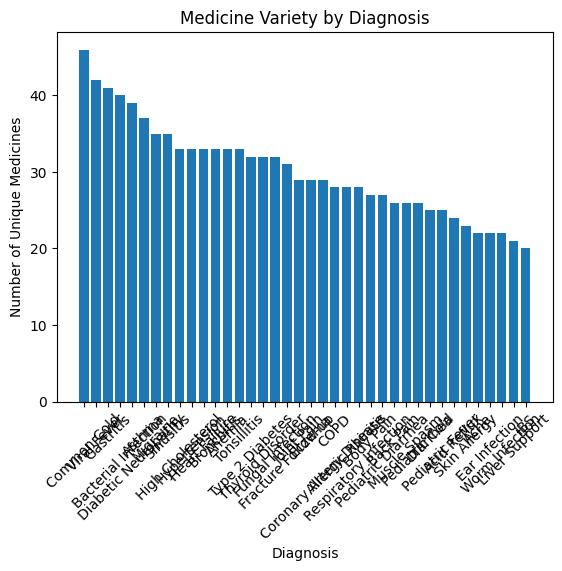

In [70]:
#39
widest_variety = df.groupby("Diagnosis")["Medicine_Name"].nunique().sort_values(ascending=False)
plt.bar(widest_variety.index, widest_variety.values)
plt.title("Medicine Variety by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Unique Medicines")
plt.xticks(rotation=45)
plt.show()

In [33]:
#42 Number of prescriptions month by month
month_by_month =df.groupby("Month")["Prescription_ID"].nunique()
print(month_by_month.groupby("Month").mean().sort_values(ascending=False))

Month
Mar    1551.0
Jan    1545.0
Apr    1462.0
Feb    1368.0
Dec     801.0
Jul     781.0
Oct     781.0
Nov     757.0
Aug     755.0
Sep     735.0
Jun     732.0
May     732.0
Name: Prescription_ID, dtype: float64


In [37]:
#53 Doctors with highest unique prescriptions and patients
doctors_with_patients = df.groupby("Doctor_ID").agg(
    Unique_Prescriptions=("Prescription_ID", "nunique"),
    Unique_Patients=("Patient_ID", "nunique")).sort_values("Unique_Prescriptions", ascending=False)
print(doctors_with_patients)

           Unique_Prescriptions  Unique_Patients
Doctor_ID                                       
DOC010                      103              103
DOC122                      103              103
DOC021                      103              101
DOC033                       98               97
DOC031                       98               95
...                         ...              ...
DOC149                       63               62
DOC057                       62               62
DOC142                       61               60
DOC063                       60               60
DOC071                       52               52

[150 rows x 2 columns]


In [38]:
#54 Doctors with highest total expenditure
total_exp = df.groupby("Doctor_ID")["Total_Medicine_Cost"].sum().sort_values(ascending=False)
print(total_exp)

Doctor_ID
DOC031    594919.31
DOC122    586975.64
DOC014    581030.20
DOC080    563122.78
DOC021    561114.57
            ...    
DOC063    345520.77
DOC133    335570.73
DOC142    327945.03
DOC057    316746.24
DOC071    291903.53
Name: Total_Medicine_Cost, Length: 150, dtype: float64


In [41]:
#61 Correlation between age, quantity, unit price and cost
correlation_bw_AQUC = df[["Patient_Age","Quantity","Unit_Price","Total_Medicine_Cost"]].corr()
print(correlation_bw_AQUC)

                     Patient_Age  Quantity  Unit_Price  Total_Medicine_Cost
Patient_Age             1.000000  0.179561   -0.005540             0.117797
Quantity                0.179561  1.000000   -0.005137             0.666861
Unit_Price             -0.005540 -0.005137    1.000000             0.650780
Total_Medicine_Cost     0.117797  0.666861    0.650780             1.000000


In [71]:
#70 the areas should be prioritised for prescription-cost management
areas = df.groupby("Department").agg(
    Prescription_Volume=("Prescription_ID", "nunique"),
    Total_Expenditure=("Total_Medicine_Cost", "sum"),
    Average_Cost=("Total_Medicine_Cost", "mean"))
print( areas.sort_values("Total_Expenditure",ascending=False))

                  Prescription_Volume  Total_Expenditure  Average_Cost
Department                                                            
General Medicine                 2843        17179178.03   1904.776364
Cardiology                       1238         8608065.55   2143.976476
Pulmonology                      1210         8465203.35   1908.296517
Endocrinology                    1201         7450427.29   2098.711913
Orthopedics                      1110         6460344.85   2010.689340
ENT                              1191         6424575.27   1831.406861
Dermatology                       941         5085307.56   2032.497026
Gastroenterology                  854         4092026.98   1788.473330
Pediatrics                       1412         2836471.32    809.495240


In [2]:
# pandas for working with the dataset
import pandas as pd
# numpy for numerical operations
import numpy as np
# matplotlib for plots
import matplotlib.pyplot as plt
# seaborn for statistical plots
import seaborn as sns
# show all columns while inspecting the data
pd.set_option('display.max_columns', None)
# avoid cutting off longer text values
pd.set_option('display.max_colwidth', 100)
#All the required libraries are imported successfully for data analysis and visualization. The settings are also changed to view the dataset properly.

In [4]:
# Define the portable dataset path so the notebook can run on different computers.
DATA_PATH = "healthcare_prescription_analytics_dataset.csv"
# read the healthcare prescription CSV file into a pandas DataFrame.
df = pd.read_csv(DATA_PATH)
# display the first five records to verify that the dataset loaded successfully.
df.head()
#The healthcare prescription dataset is loaded successfully into a DataFrame. The first five records are displayed to check the data.

,Prescription_ID,Patient_ID,Patient_Age,Age_Group,Gender,City,Department,Diagnosis,Medicine_Name,Medicine_Category,Dosage,Quantity,Unit_Price,Total_Medicine_Cost,Prescription_Date,Month,Season,Doctor_ID
0,RX000001,PAT01144,47,Adult,Female,Indore,General Medicine,Migraine,Pantoprazole,Antacid/PPI,40mg,13,321.57,4180.41,2025-11-24,Nov,Winter,DOC027
1,RX000001,PAT01144,47,Adult,Female,Indore,General Medicine,Migraine,Ondansetron,Antiemetic,250mg,12,139.62,1675.44,2025-11-24,Nov,Winter,DOC027
2,RX000002,PAT01274,35,Young Adult,Female,Hyderabad,Orthopedics,Fracture Follow-up,Calcium,Supplement,5ml,15,38.68,580.20,2026-01-24,Jan,Winter,DOC056
3,RX000002,PAT01274,35,Young Adult,Female,Hyderabad,Orthopedics,Fracture Follow-up,Vitamin D3,Vitamin/Supplement,10mg,9,53.88,484.92,2026-01-24,Jan,Winter,DOC056
4,RX000003,PAT01576,50,Adult,Female,Pune,ENT,Ear Infection,Paracetamol,Analgesic/Antipyretic,500mg,5,179.18,895.90,2026-03-01,Mar,Summer,DOC018


In [5]:
# Quickly display the first five records to understand the dataset structure.
df.head()
#The first five rows of the dataset are displayed to get a basic idea about the data and its columns.

,Prescription_ID,Patient_ID,Patient_Age,Age_Group,Gender,City,Department,Diagnosis,Medicine_Name,Medicine_Category,Dosage,Quantity,Unit_Price,Total_Medicine_Cost,Prescription_Date,Month,Season,Doctor_ID
0,RX000001,PAT01144,47,Adult,Female,Indore,General Medicine,Migraine,Pantoprazole,Antacid/PPI,40mg,13,321.57,4180.41,2025-11-24,Nov,Winter,DOC027
1,RX000001,PAT01144,47,Adult,Female,Indore,General Medicine,Migraine,Ondansetron,Antiemetic,250mg,12,139.62,1675.44,2025-11-24,Nov,Winter,DOC027
2,RX000002,PAT01274,35,Young Adult,Female,Hyderabad,Orthopedics,Fracture Follow-up,Calcium,Supplement,5ml,15,38.68,580.20,2026-01-24,Jan,Winter,DOC056
3,RX000002,PAT01274,35,Young Adult,Female,Hyderabad,Orthopedics,Fracture Follow-up,Vitamin D3,Vitamin/Supplement,10mg,9,53.88,484.92,2026-01-24,Jan,Winter,DOC056
4,RX000003,PAT01576,50,Adult,Female,Pune,ENT,Ear Infection,Paracetamol,Analgesic/Antipyretic,500mg,5,179.18,895.90,2026-03-01,Mar,Summer,DOC018


In [6]:
# display the final five records to verify the dataset ending and formatting.
df.tail()
#The last five rows of the dataset are displayed to check the ending records and data format.

,Prescription_ID,Patient_ID,Patient_Age,Age_Group,Gender,City,Department,Diagnosis,Medicine_Name,Medicine_Category,Dosage,Quantity,Unit_Price,Total_Medicine_Cost,Prescription_Date,Month,Season,Doctor_ID
36030,RX011998,PAT03801,7,Child,Male,Delhi,Pediatrics,Pediatric Diarrhea,Zinc Syrup,Pediatric Supplement,5ml,1,191.19,191.19,2025-08-17,Aug,Monsoon,DOC039
36031,RX011999,PAT02427,36,Adult,Male,Bengaluru,ENT,Tonsillitis,Azithromycin,Antibiotic,500mg,14,183.93,2575.02,2025-05-26,May,Summer,DOC049
36032,RX011999,PAT02427,36,Adult,Male,Bengaluru,ENT,Tonsillitis,Paracetamol,Analgesic/Antipyretic,500mg,5,296.67,1483.35,2025-05-26,May,Summer,DOC049
36033,RX012000,PAT02859,20,Young Adult,Male,Pune,ENT,Ear Infection,Probiotic,Gut Health,Capsule,6,91.38,548.28,2026-03-04,Mar,Summer,DOC064
36034,RX012000,PAT02859,20,Young Adult,Male,Pune,ENT,Ear Infection,Amoxicillin Clavulanate,Antibiotic,10mg,10,60.13,601.30,2026-03-04,Mar,Summer,DOC064


In [8]:
# inspect the number of rows and columns available in the dataset.
df.shape
#The dataset contains a specific number of rows and columns, which shows the overall size of the dataset.

(36035, 18)

In [9]:
# list every column name to understand the available analytical variables.
df.columns.tolist()
#The column names are displayed, which helps us understand the different variables available in the dataset.

['Prescription_ID',
 'Patient_ID',
 'Patient_Age',
 'Age_Group',
 'Gender',
 'City',
 'Department',
 'Diagnosis',
 'Medicine_Name',
 'Medicine_Category',
 'Dosage',
 'Quantity',
 'Unit_Price',
 'Total_Medicine_Cost',
 'Prescription_Date',
 'Month',
 'Season',
 'Doctor_ID']

In [10]:
# inspect data types, non-null counts, and memory usage.
df.info()
#The info() output shows the data types and non-null values of each column. It helps us check the overall structure of the dataset.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36035 entries, 0 to 36034
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Prescription_ID      36035 non-null  object 
 1   Patient_ID           36035 non-null  object 
 2   Patient_Age          36035 non-null  int64  
 3   Age_Group            36035 non-null  object 
 4   Gender               36035 non-null  object 
 5   City                 36035 non-null  object 
 6   Department           36035 non-null  object 
 7   Diagnosis            35689 non-null  object 
 8   Medicine_Name        36035 non-null  object 
 9   Medicine_Category    36035 non-null  object 
 10  Dosage               36035 non-null  object 
 11  Quantity             36035 non-null  int64  
 12  Unit_Price           36035 non-null  float64
 13  Total_Medicine_Cost  36035 non-null  float64
 14  Prescription_Date    36035 non-null  object 
 15  Month                36035 non-null 

In [11]:
# Statistically summarize the numerical columns using count, mean, spread, and quartiles.
df.describe()
#The describe() output gives the basic statistics of the numerical columns, such as mean, minimum, maximum, and quartiles.

,Patient_Age,Quantity,Unit_Price,Total_Medicine_Cost
count,36035.000000,36035.000000,36035.000000,36035.000000
mean,37.882226,7.923269,233.616176,1848.247543
std,21.300251,4.316388,124.320632,1505.398833
min,1.000000,1.000000,20.000000,20.120000
25%,22.000000,4.000000,126.270000,637.425000
50%,38.000000,8.000000,232.770000,1399.100000
75%,53.000000,12.000000,341.510000,2733.360000
max,92.000000,15.000000,450.000000,6746.850000


In [12]:
# summarize the categorical columns to inspect unique and dominant values.
df.describe(include='object')
#The categorical columns are summarized with their unique values and most common values. This helps us understand the categorical data better.

,Prescription_ID,Patient_ID,Age_Group,Gender,City,Department,Diagnosis,Medicine_Name,Medicine_Category,Dosage,Prescription_Date,Month,Season,Doctor_ID
count,36035,36035,36035,36035,36035,36035,35689,36035,36035,36035,36035,36035,36035,36035
unique,12000,4848,6,3,10,9,38,115,33,14,485,12,3,150
top,RX005644,PAT01925,Adult,Male,Nagpur,General Medicine,Common Cold,Pantoprazole,Vitamin/Supplement,500mg,2025-10-12,Jan,Summer,DOC021
freq,6,33,9538,18248,3821,9019,2374,2777,3466,8096,139,4653,13456,316


In [14]:
# count missing values in every column to identify incomplete information.
missing_values = df.isnull().sum()

# display the missing-value count for each column.
missing_values

#The missing values in each column are counted. This helps us identify which columns have incomplete data.

Prescription_ID          0
Patient_ID               0
Patient_Age              0
Age_Group                0
Gender                   0
City                     0
Department               0
Diagnosis              346
Medicine_Name            0
Medicine_Category        0
Dosage                   0
Quantity                 0
Unit_Price               0
Total_Medicine_Cost      0
Prescription_Date        0
Month                    0
Season                   0
Doctor_ID                0
dtype: int64

In [15]:
# calculate the percentage of missing values in each column.
missing_percentage = (df.isnull().sum() / len(df)) * 100

# display missing-value percentages in descending order.
missing_percentage.sort_values(ascending=False)

#The missing-value percentage for each column is calculated and sorted. This helps us identify the columns with the highest missing data.

Diagnosis              0.960178
Prescription_ID        0.000000
Dosage                 0.000000
Season                 0.000000
Month                  0.000000
Prescription_Date      0.000000
Total_Medicine_Cost    0.000000
Unit_Price             0.000000
Quantity               0.000000
Medicine_Category      0.000000
Patient_ID             0.000000
Medicine_Name          0.000000
Department             0.000000
City                   0.000000
Gender                 0.000000
Age_Group              0.000000
Patient_Age            0.000000
Doctor_ID              0.000000
dtype: float64

In [16]:
# count exact duplicate rows to identify redundant records.
duplicate_rows = df.duplicated().sum()

# display the total number of exact duplicate rows.
duplicate_rows

#The duplicate rows are counted to check for repeated records in the dataset. This helps us identify any unnecessary duplicate data.

np.int64(0)

In [17]:
# inspect records where the diagnosis value is missing.
df[df['Diagnosis'].isnull()].head(10)
#The records with missing diagnosis values are displayed. This helps us identify incomplete diagnosis information in the dataset.

,Prescription_ID,Patient_ID,Patient_Age,Age_Group,Gender,City,Department,Diagnosis,Medicine_Name,Medicine_Category,Dosage,Quantity,Unit_Price,Total_Medicine_Cost,Prescription_Date,Month,Season,Doctor_ID
12,RX000006,PAT04399,33,Young Adult,Female,Hyderabad,Gastroenterology,NaN,Probiotic,Gut Health,Capsule,14,133.26,1865.64,2026-03-17,Mar,Summer,DOC069
13,RX000006,PAT04399,33,Young Adult,Female,Hyderabad,Gastroenterology,NaN,Zinc,Supplement,50mg,11,412.43,4536.73,2026-03-17,Mar,Summer,DOC069
146,RX000052,PAT01675,30,Young Adult,Female,Nagpur,General Medicine,NaN,Vitamin B12,Vitamin/Supplement,Capsule,5,75.55,377.75,2025-01-24,Jan,Winter,DOC078
147,RX000052,PAT01675,30,Young Adult,Female,Nagpur,General Medicine,NaN,Vitamin C,Vitamin/Supplement,500mg,13,366.67,4766.71,2025-01-24,Jan,Winter,DOC078
325,RX000111,PAT00397,1,Child,Male,Mumbai,Dermatology,NaN,Cetirizine,Antihistamine,10mg,14,411.05,5754.70,2025-10-17,Oct,Summer,DOC012
326,RX000111,PAT00397,1,Child,Male,Mumbai,Dermatology,NaN,Calamine Lotion,Dermatology,10mg,7,60.14,420.98,2025-10-17,Oct,Summer,DOC012
327,RX000111,PAT00397,1,Child,Male,Mumbai,Dermatology,NaN,Steroid Cream,Dermatology,Tablet,8,305.74,2445.92,2025-10-17,Oct,Summer,DOC012
330,RX000113,PAT00846,39,Adult,Male,Hyderabad,General Medicine,NaN,Vitamin C,Vitamin/Supplement,500mg,14,111.61,1562.54,2025-02-06,Feb,Winter,DOC081
331,RX000113,PAT00846,39,Adult,Male,Hyderabad,General Medicine,NaN,Cetirizine,Antihistamine,10mg,13,210.23,2732.99,2025-02-06,Feb,Winter,DOC081
332,RX000113,PAT00846,39,Adult,Male,Hyderabad,General Medicine,NaN,Paracetamol,Analgesic/Antipyretic,500mg,15,72.96,1094.40,2025-02-06,Feb,Winter,DOC081


In [18]:
# replace missing diagnosis values with the meaningful label 'Unknown'.
df['Diagnosis'] = df['Diagnosis'].fillna('Unknown')

# verify that diagnosis values no longer contain null entries.
df['Diagnosis'].isnull().sum()

#The missing diagnosis values are replaced with "Unknown". After checking, there are no missing values left in the Diagnosis column.

np.int64(0)

In [19]:
# count medicine-name occurrences to detect spelling inconsistencies.
medicine_name_counts = df['Medicine_Name'].value_counts()

# display all medicine frequencies for inspection.
medicine_name_counts

#The frequency of each medicine name is displayed. This helps us identify common medicines and possible spelling inconsistencies.

Medicine_Name
Pantoprazole        2777
Cetirizine          2617
Paracetamol         2326
Probiotic           1958
Cough Syrup         1386
                    ... 
PARACETMOL             1
PANTAPRAZOLE           1
GLIMEPIRIDE            1
BENZOYL PEROXIDE       1
AMLODIPINE             1
Name: count, Length: 115, dtype: int64

In [20]:
# standardize known medicine spelling variations into consistent names.
df['Medicine_Name'] = df['Medicine_Name'].replace({
    'Paracetmol': 'Paracetamol',
    'Vit C': 'Vitamin C',
    'Azithrocin': 'Azithromycin'
})

# recount medicine names to confirm successful standardization.
df['Medicine_Name'].value_counts()

#The medicine name spelling variations are corrected and standardized. The medicine names are now more consistent in the dataset.

Medicine_Name
Pantoprazole    2777
Cetirizine      2617
Paracetamol     2392
Probiotic       1958
Cough Syrup     1386
                ... 
AZITHROCIN         1
PARACETMOL         1
PANTAPRAZOLE       1
GLIMEPIRIDE        1
AMLODIPINE         1
Name: count, Length: 112, dtype: int64

In [21]:
# display all unique medicine categories available in the dataset.
df['Medicine_Category'].unique()

#Observation:The unique medicine categories in the dataset are displayed. This helps us understand the different types of medicines available.

array(['Antacid/PPI', 'Antiemetic', 'Supplement', 'Vitamin/Supplement',
       'Analgesic/Antipyretic', 'Antibiotic', 'ENT', 'Antihistamine',
       'Anti-allergic', 'Respiratory', 'Bronchodilator', 'Gut Health',
       'Topical Analgesic', 'Steroid/Inhaler', 'Diuretic',
       'Antihypertensive', 'Statin', 'Antiplatelet', 'Dermatology',
       'Muscle Relaxant', 'NSAID', 'Antidiabetic', 'Neuropathic Pain',
       'Pediatric Supplement', 'Anti-parasitic', 'Antifungal',
       'Supportive Care', 'Rehydration', 'Antacid', 'Thyroid Medicine',
       'Pediatric', 'Liver Medicine', 'Antispasmodic'], dtype=object)

In [22]:
# display all unique diagnoses available after cleaning.
df['Diagnosis'].unique()

#The unique diagnosis values are displayed after cleaning. This helps us understand the different diagnoses present in the dataset.

array(['Migraine', 'Fracture Follow-up', 'Ear Infection',
       'Allergic Rhinitis', 'Bronchitis', 'Unknown', 'Asthma',
       'Gastritis', 'Heart Failure', 'Sinusitis', 'Common Cold',
       'Hypertension', 'Acne', 'Coronary Artery Disease', 'Muscle Spasm',
       'Eczema', 'Diabetic Neuropathy', 'Type 2 Diabetes',
       'Worm Infection', 'Viral Fever', 'Fungal Infection', 'Back Pain',
       'High Cholesterol', 'Bacterial Infection', 'COPD', 'Diarrhea',
       'Anemia', 'IBS', 'Joint Pain', 'Thyroid Disorder', 'Liver Support',
       'Tonsillitis', 'Pediatric Cold', 'Pediatric Diarrhea',
       'Skin Allergy', 'Acid Reflux', 'Body Pain', 'Pediatric Fever',
       'Respiratory Infection'], dtype=object)

In [24]:
# display all unique hospital departments represented in the dataset.
df['Department'].unique()
#The unique hospital departments are displayed. This helps us understand which departments are included in the dataset.

array(['General Medicine', 'Orthopedics', 'ENT', 'Pulmonology',
       'Gastroenterology', 'Cardiology', 'Dermatology', 'Endocrinology',
       'Pediatrics'], dtype=object)

In [25]:
# convert the prescription-date column into a proper datetime format.
df['Prescription_Date'] = pd.to_datetime(df['Prescription_Date'])

# extract the calendar year for yearly healthcare trend analysis.
df['Year'] = df['Prescription_Date'].dt.year

# extract the numeric month for chronological grouping.
df['Month_Number'] = df['Prescription_Date'].dt.month

# extract the readable month name for intuitive visualizations.
df['Month_Name'] = df['Prescription_Date'].dt.month_name()

# extract the quarter for quarterly prescription analysis.
df['Quarter'] = df['Prescription_Date'].dt.quarter

# display the newly engineered date features.
df[['Prescription_Date', 'Year', 'Month_Number', 'Month_Name', 'Quarter']].head()

#The prescription date is converted into datetime format, and new columns for year, month, and quarter are created. 
#These columns will help in analyzing prescription trends over time.

,Prescription_Date,Year,Month_Number,Month_Name,Quarter
0,2025-11-24,2025,11,November,4
1,2025-11-24,2025,11,November,4
2,2026-01-24,2026,1,January,1
3,2026-01-24,2026,1,January,1
4,2026-03-01,2026,3,March,1


In [26]:
# count medicine occurrences and select the ten most frequently prescribed medicines.
top_medicines = df['Medicine_Name'].value_counts().head(10)

# display the top ten medicines and their frequencies.
top_medicines

#The top 10 most frequently prescribed medicines are identified based on their prescription counts.
#This shows which medicines are prescribed the most.

Medicine_Name
Pantoprazole    2777
Cetirizine      2617
Paracetamol     2392
Probiotic       1958
Cough Syrup     1386
Azithromycin    1357
Vitamin C       1169
Vitamin B12     1089
Vitamin D3      1015
Calcium          995
Name: count, dtype: int64

Text(0, 0.5, 'Prescription Row Count')

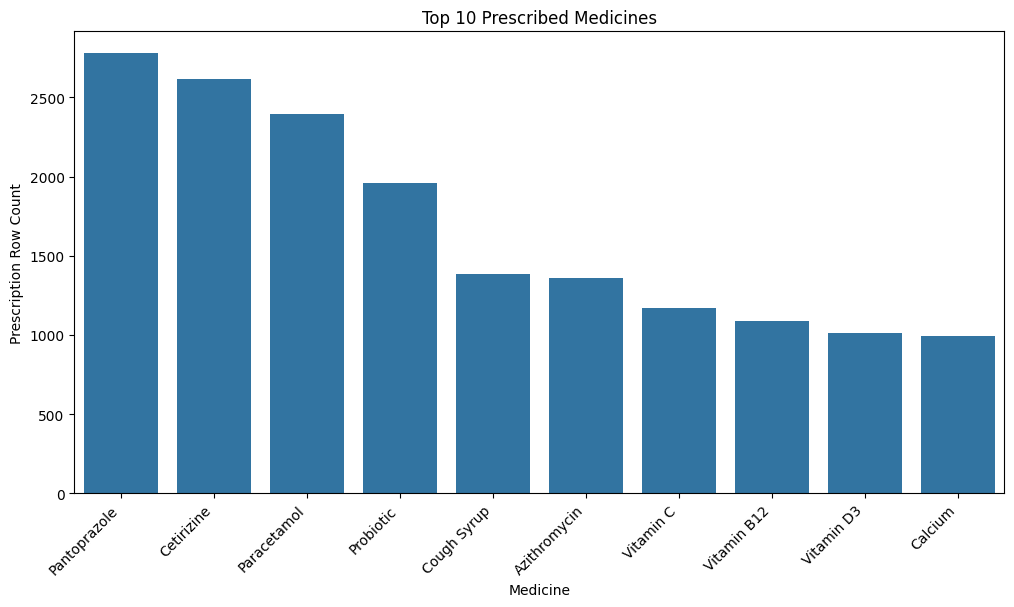

In [27]:
# set the figure size for a readable medicine-frequency chart.
plt.figure(figsize=(12, 6))

# plot the top ten medicines using an informative bar chart.
sns.barplot(x=top_medicines.index, y=top_medicines.values)

# rotate medicine labels to prevent overlapping text.
plt.xticks(rotation=45, ha='right')

# add a title to the visualization.
plt.title("Top 10 Prescribed Medicines")

# label the horizontal axis.
plt.xlabel("Medicine")

# label the vertical axis.
plt.ylabel("Prescription Row Count")

#The bar chart shows the top 10 prescribed medicines and their prescription counts. 
#It helps us easily compare which medicines are prescribed more frequently.

In [28]:
# count prescription rows handled by each department.
department_counts = df['Department'].value_counts()

# display department-level prescription volume.
department_counts

#The number of prescriptions handled by each department is shown. This helps us identify which department has more prescription records.

Department
General Medicine    9019
Pulmonology         4436
Cardiology          4015
Endocrinology       3550
ENT                 3508
Pediatrics          3504
Orthopedics         3213
Dermatology         2502
Gastroenterology    2288
Name: count, dtype: int64

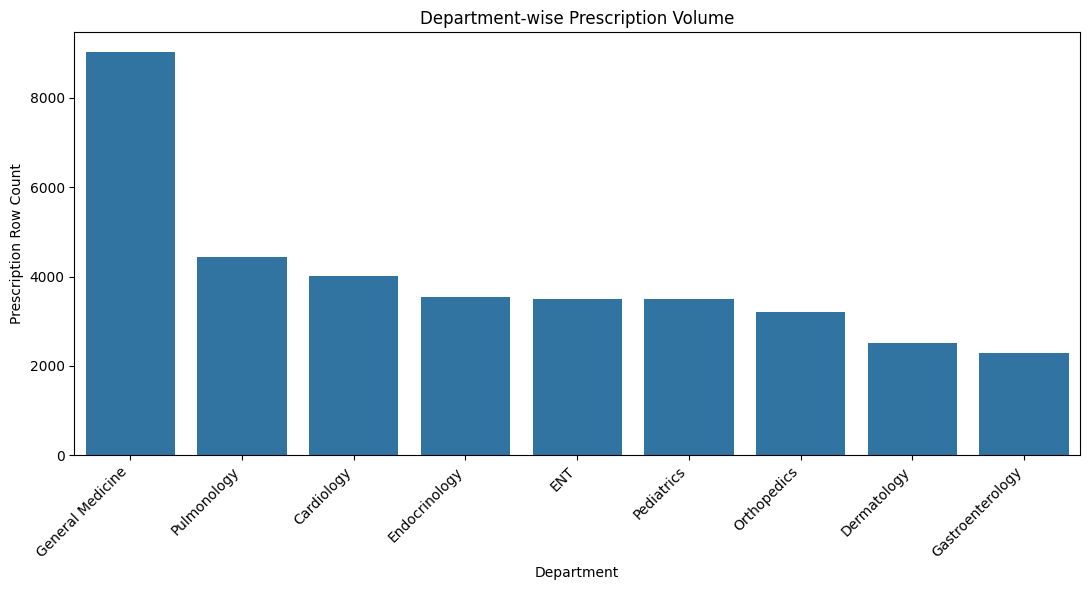

In [29]:
# set the figure size for department-level comparison.
plt.figure(figsize=(11, 6))

# plot departments in descending order of prescription-row frequency.
sns.countplot(data=df, x='Department', order=df['Department'].value_counts().index)

# rotate department labels for improved readability.
plt.xticks(rotation=45, ha='right')

# add a title to the departmental analysis.
plt.title("Department-wise Prescription Volume")

# label the horizontal axis.
plt.xlabel("Department")

# label the vertical axis.
plt.ylabel("Prescription Row Count")

# adjust spacing
plt.tight_layout()

# show the plot
plt.show()

#The bar chart compares prescription volume across different departments.
#It shows which departments have the highest and lowest number of prescription records.

In [30]:
# count the number of prescription rows associated with each diagnosis.
diagnosis_counts = df['Diagnosis'].value_counts()

# display diagnosis frequencies.
diagnosis_counts

#The number of prescriptions for each diagnosis is displayed. This helps us identify the most common and least common diagnoses in the dataset.

Diagnosis
Common Cold                2374
Viral Fever                1522
Type 2 Diabetes            1446
Gastritis                  1428
Bacterial Infection        1385
Sinusitis                  1300
Asthma                     1239
Pediatric Diarrhea         1130
Bronchitis                 1120
Hypertension               1098
Coronary Artery Disease    1087
Joint Pain                 1085
Diabetic Neuropathy        1073
Respiratory Infection      1033
COPD                       1018
Thyroid Disorder           1006
Allergic Rhinitis           970
High Cholesterol            923
Pediatric Cold              895
Pediatric Fever             886
Heart Failure               875
Diarrhea                    805
Migraine                    789
Anemia                      743
Muscle Spasm                715
Fracture Follow-up          711
Body Pain                   679
Back Pain                   673
Eczema                      647
Fungal Infection            625
Acne                        60

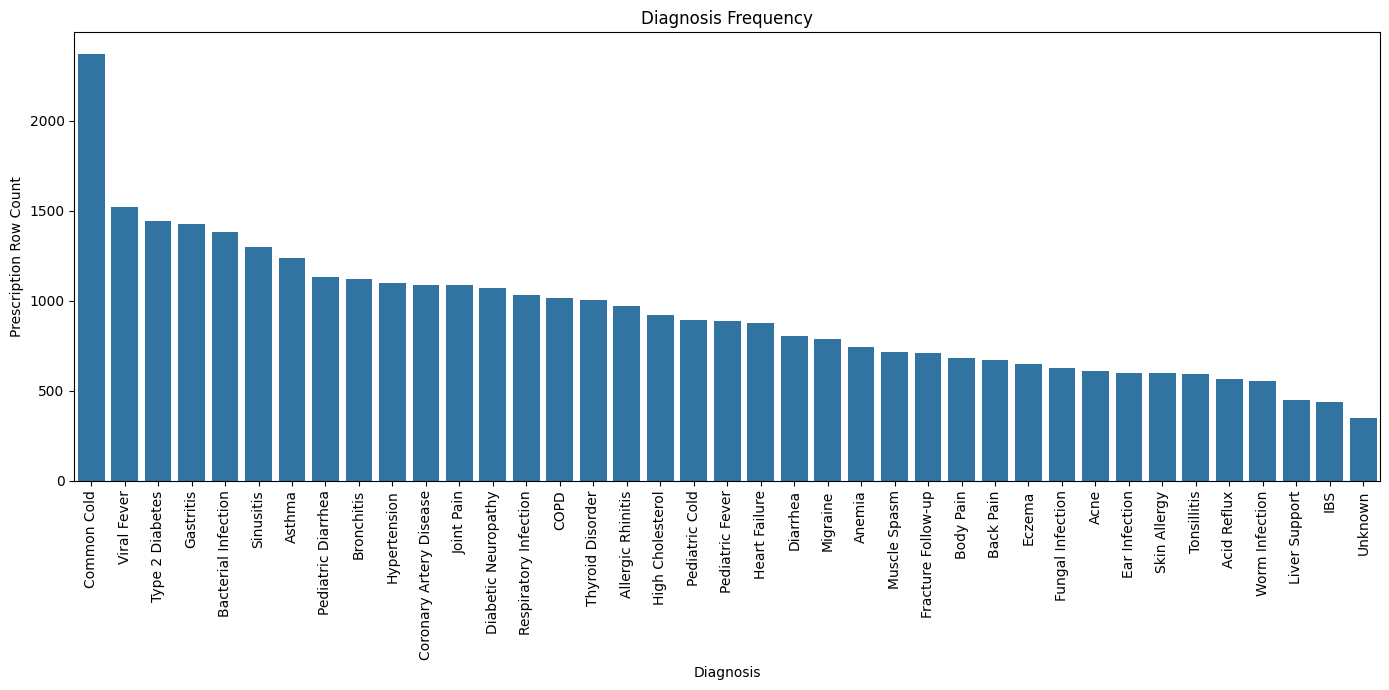

In [31]:
# set the figure size to accommodate multiple diagnosis labels.
plt.figure(figsize=(14, 7))

# compare diagnosis frequencies in descending order.
sns.countplot(data=df, x='Diagnosis', order=df['Diagnosis'].value_counts().index)

# rotate diagnosis labels to make each category readable.
plt.xticks(rotation=90)

# add a title to the diagnosis-frequency visualization.
plt.title("Diagnosis Frequency")

# label the horizontal axis.
plt.xlabel("Diagnosis")

# label the vertical axis.
plt.ylabel("Prescription Row Count")

# adjust spacing
plt.tight_layout()

# show the plot
plt.show()

#The bar chart shows the frequency of different diagnoses. It helps us identify which diagnoses have more prescription records in the dataset.

In [32]:
# count the number of records belonging to each medicine category.
medicine_category_counts = df['Medicine_Category'].value_counts()

# display medicine-category frequencies.
medicine_category_counts

#The number of prescriptions in each medicine category is displayed. This helps us see which medicine categories are more common in the dataset.

Medicine_Category
Vitamin/Supplement       3466
Antacid/PPI              2855
Antihistamine            2715
Analgesic/Antipyretic    2418
Supplement               2189
Gut Health               1969
Antibiotic               1780
Respiratory              1401
Dermatology              1272
Antihypertensive         1235
Antidiabetic             1149
Antiplatelet             1088
Bronchodilator           1082
Pediatric Supplement      990
NSAID                     966
Rehydration               928
Pediatric                 920
Antiemetic                919
Statin                    889
Anti-allergic             869
Antacid                   641
ENT                       637
Steroid/Inhaler           563
Diuretic                  548
Muscle Relaxant           450
Neuropathic Pain          362
Supportive Care           329
Thyroid Medicine          327
Anti-parasitic            294
Topical Analgesic         254
Antifungal                217
Liver Medicine            160
Antispasmodic         